### Name: Silva Alejandro
### Affiliation: Yachay Tech University, School of Physical Sciences and Nanotechnology
### Class: Dynamical Systems, lectured by Prof. Mario Cosenza.
### Date: 06/03/2026
### Mail: alejandro.silva@yachaytech.edu.ec

# 1. Consider the following dynamical system with $a,b \in \mathbb{R}$,
$$
\begin{cases}
\dot{x} = y - ax, \\
\dot{y} = \dfrac{x^2}{1+x^2} - by.
\end{cases}
$$

## a) Find the fixed points for this system and classify them according to their stability.

The fixed points are given by,
$$
f_1(x^*,y^*) = y^* - ax^* = 0,
$$
$$
f_2(x^*,y^*) = \frac{x^*²}{1 + x^*²} - by^*= 0.
$$

We solve the system of equations.
$$
y^* = ax^*,
$$
$$
abx^*³ - x^*² + abx^* = 0,
$$
$$
x^*(abx^*² - x^* + ab) = 0.
$$
$$
\Rightarrow x^*_{1} = 0, x^*_{2,3} = \frac{1 \pm \sqrt{1 - 4 a² b²}}{2 ab}.
$$
Finally,
$$
\begin{gathered}
(x^*_{1}, y^*_{1}) = (0,0) \\
(x^*_{2}, y^*_{2}) = \left(\frac{1 + \sqrt{1 - 4 a^{2} b^{2}}}{2ab}, \frac{1 + \sqrt{1 - 4 a^{2} b^{2}}}{2b}\right) \\
(x^*_{3}, y^*_{3}) = \left(\frac{1 - \sqrt{1 - 4 a^{2} b^{2}}}{2ab}, \frac{1 - \sqrt{1 - 4 a^{2} b^{2}}}{2b}\right)
\end{gathered}
$$

The second and third fixed points are real iff,
$$
1 - 4 a^{2} b^{2} \ge 0,
$$
$$
|ab| \le \frac{1}{2},
$$

To classify the fixed points according to their stability we define the Jacobian for the system and evaluate it at each fixed point.
$$
J(\mathbf{x}^*) =
\begin{pmatrix}
-a & 1 \\
\frac{2x^*}{(1 + x*²)²} & -b
\end{pmatrix}
$$

- For $(x^*_{1}, y^*_{1})$,
$$
J(\mathbf{x}^*) =
\begin{pmatrix}
-a & 1 \\
0 & -b
\end{pmatrix}
$$

In [1]:
# We use sympy to find the eigenvalues
import sympy as sp

# Define symbols and the matrix
a, b = sp.symbols('a b')

A_1 = sp.Matrix([[-a, 1],
                 [0, -b]])

# Compute symbolic eigenvalues
eig_1 = A_1.eigenvals()
# Get them as a list
eig_list = list(eig_1.keys())
print(eig_list)

[-b, -a]


Recall that $a,b \in \mathbb{R}$. If $a,b > 0$ then $(x^*_{1}, y^*_{1})$ is a stable node. If $a,b$ < 0, then it's an unstable node. Finally, if one is positive and the other negative, $(x^*_{1}, y^*_{1})$ is a saddle point.

- For $(x^*_{2}, y^*_{2})$,
$$
J(\mathbf{x}^*) =
\begin{pmatrix}
-a & 1 \\
\dfrac{
\frac{1 + \sqrt{1 - 4 a^{2} b^{2}}}{ab}
}{
\left(
1 +
\left(
\frac{1 + \sqrt{1 - 4 a^{2} b^{2}}}{2ab}
\right)^{2}
\right)^{2}
}
& -b
\end{pmatrix}
$$

Solving in Mathematica, we get the following eigenvalues,
$$
\omega_{2 1} = \frac{1}{2}(- (a + b) - \sqrt{(a + b)² - 4ab \sqrt{1 - 4 a² b²}}),
$$
$$
\omega_{2 2} = \frac{1}{2}(- (a + b) + \sqrt{(a + b)² - 4ab \sqrt{1 - 4 a² b²}}).
$$

Now, we evaluate the possible cases by defining a function.

In [2]:
# Import numpy library
import numpy as np

# Define a function to evaluate for different values of a,b
def omega2_values(a, b):
    '''
    Computes the eigenvalue given values of the parameters a,b.
    Inputs -> a,b (real numbers, float).
    Outputs -> omega21, omega22 (float).
    '''
    term = np.sqrt((a + b)**2 - 4*a*b*np.sqrt(1 - 4*a**2*b**2))
    
    omega21 = 0.5 * (-a - b - term)
    omega22 = 0.5 * (-a - b + term)
    
    return omega21, omega22

# Function to classify stability
def classify_fixed_points(w1, w2):
    '''
    Classifies the stability of fixed points by analyzing the nature of the eigenvalues.
    Inputs -> w1, w2 (float).
    Output -> str.
    '''
    
    if w1 < 0 and w2 < 0:
        return "Stable node (both eigenvalues negative)."
    
    elif w1 > 0 and w2 > 0:
        return "Unstable node (both eigenvalues positive)."
    
    elif w1 * w2 < 0:
        return "Saddle point (eigenvalues have opposite sign)."
        
    else:
        return "Indeterminate case."


# Test cases
cases = [
    ("a,b positive", 2.6, 0.025),
    ("a,b negative", -0.023, -2),
    ("a,b opposite signs", -0.023, 3),
    ("One parameter is zero", 0, -3.2)
]


# Evaluate each case
for name, a, b in cases:

    # Call our eigenvalue function
    w21, w22 = omega2_values(a, b)
    
    print("--------------------------------------------------")
    print(f"Case: {name}")
    print(f"a = {a}, b = {b}")
    
    print(f"ω21 = {w21:.6f}")
    print(f"ω22 = {w22:.6f}")

    # Classify according to stability
    stability = classify_fixed_points(w21, w22)
    
    print("Classification:", stability)
    print("Recall the condition |ab| ≤ 0.5.\n")

--------------------------------------------------
Case: a,b positive
a = 2.6, b = 0.025
ω21 = -2.600214
ω22 = -0.024786
Classification: Stable node (both eigenvalues negative).
Recall the condition |ab| ≤ 0.5.

--------------------------------------------------
Case: a,b negative
a = -0.023, b = -2
ω21 = 0.022901
ω22 = 2.000099
Classification: Unstable node (both eigenvalues positive).
Recall the condition |ab| ≤ 0.5.

--------------------------------------------------
Case: a,b opposite signs
a = -0.023, b = 3
ω21 = -2.999782
ω22 = 0.022782
Classification: Saddle point (eigenvalues have opposite sign).
Recall the condition |ab| ≤ 0.5.

--------------------------------------------------
Case: One parameter is zero
a = 0, b = -3.2
ω21 = 0.000000
ω22 = 3.200000
Classification: Indeterminate case.
Recall the condition |ab| ≤ 0.5.



- For $(x^*_{3}, y^*_{3})$,
$$
J(\mathbf{x}^*) =
\begin{pmatrix}
-a & 1 \\
\dfrac{
\frac{1 - \sqrt{1 - 4 a^{2} b^{2}}}{ab}
}{
\left(
1 +
\left(
\frac{1 - \sqrt{1 - 4 a^{2} b^{2}}}{2ab}
\right)^{2}
\right)^{2}
}
& -b
\end{pmatrix}
$$

Solving in Mathematica, we get the following eigenvalues,
$$
\omega_{3 1} = \frac{1}{2}(- (a + b) - \sqrt{(a + b)² + 4ab \sqrt{1 - 4 a² b²}}),
$$
$$
\omega_{3 2} = \frac{1}{2}(- (a + b) + \sqrt{(a + b)² + 4ab \sqrt{1 - 4 a² b²}}).
$$
Now, we evaluate the possible cases by defining a function.

In [3]:
# Define a function to evaluate for different values of a,b
def omega3_values(a, b):
    '''
    Computes the eigenvalue given values of the parameters a,b.
    Inputs -> a,b (real numbers, float).
    Outputs -> omega31, omega32 (float).
    '''
    term = np.sqrt((a + b)**2 + 4*a*b*np.sqrt(1 - 4*a**2*b**2))
    
    omega31 = 0.5 * (-a - b - term)
    omega32 = 0.5 * (-a - b + term)
    
    return omega31, omega32

# Function to classify stability
def classify_fixed_points(w1, w2):
    '''
    Classifies the stability of fixed points by analyzing the nature of the eigenvalues.
    Inputs -> w1, w2 (float).
    Output -> str.
    '''
    
    if w1 < 0 and w2 < 0:
        return "Stable node (both eigenvalues negative)."
    
    elif w1 > 0 and w2 > 0:
        return "Unstable node (both eigenvalues positive)."
    
    elif w1 * w2 < 0:
        return "Saddle point (eigenvalues have opposite sign)."
        
    else:
        return "Indeterminate case."


# Test cases
cases = [
    ("a,b positive", 2.6, 0.025),
    ("a,b negative", -0.023, -2),
    ("a,b opposite signs", -0.023, 3),
    ("One parameter is zero", 2.6, 0)
]


# Evaluate each case
for name, a, b in cases:

    # Call our eigenvalue function
    w31, w32 = omega3_values(a, b)
    
    print("--------------------------------------------------")
    print(f"Case: {name}")
    print(f"a = {a}, b = {b}")
    
    print(f"ω31 = {w31:.6f}")
    print(f"ω32 = {w32:.6f}")

    # Classify according to stability
    stability = classify_fixed_points(w31, w32)
    
    print("Classification:", stability)
    print("Recall the condition |ab| ≤ 0.5.\n")

--------------------------------------------------
Case: a,b positive
a = 2.6, b = 0.025
ω31 = -2.649326
ω32 = 0.024326
Classification: Saddle point (eigenvalues have opposite sign).
Recall the condition |ab| ≤ 0.5.

--------------------------------------------------
Case: a,b negative
a = -0.023, b = -2
ω31 = -0.022394
ω32 = 2.045394
Classification: Saddle point (eigenvalues have opposite sign).
Recall the condition |ab| ≤ 0.5.

--------------------------------------------------
Case: a,b opposite signs
a = -0.023, b = 3
ω31 = -2.953864
ω32 = -0.023136
Classification: Stable node (both eigenvalues negative).
Recall the condition |ab| ≤ 0.5.

--------------------------------------------------
Case: One parameter is zero
a = 2.6, b = 0
ω31 = -2.600000
ω32 = 0.000000
Classification: Indeterminate case.
Recall the condition |ab| ≤ 0.5.



## b) Is there chaos for some range of parameters $a$ and $b$?

For continuous dynamical systems we need at least 3 dimensions in phase space for chaos to emerge, according to the Poincaré-Bendixon theorem. Thus, for 2D dynamical systems the phase space can only have fixed points and pediodic orbits. Then, there is no chaos for any range of $a,b$.

# 2. Consider the system  
$$
\ddot{x} + \lambda (x^2 - 1)\dot{x} + x - a = 0.
$$

## a) Find the fixed points for this system.

We do an order reduction to have a dynamical system.
$$
\begin{cases}
\dot{x} = y, \\
\dot{y} = -\lambda(x²- 1)y - x + a.
\end{cases}
$$

Then, the fixed points are given by,
$$
f_1(x^*,y^*) = y^* = 0,
$$
$$
f_2(x^*,y^*) = -\lambda(x^*²- 1)y^* - x^* + a= 0.
$$

So, the only fixed point is,
$$
(x^*,y^*) = (a,0). 
$$

## b) Find the curves in the space of parameters $(\lambda, a)$ where a Hopf bifurcation occurs.

We define the Jacobian for the system and evaluate it at the fixed point.
$$
J(\mathbf{x}^*) =
\begin{pmatrix}
0 & 1 \\
-\lambda (2 x^* y^*) - 1 & -\lambda(x^*² - 1)
\end{pmatrix},
$$
$$
\Rightarrow J(\mathbf{x}^*) =
\begin{pmatrix}
0 & 1 \\
-1 & -\lambda(a^² - 1)
\end{pmatrix}.
$$

Then, we find the eigenvalues at the fixed point and analyze them to see if they fullfill the necessary conditions for a Hopf bifurcation.
Solving in Mathematica, we get the following eigenvalues,
$$
\omega_{1} = \frac{1}{2}\left(-\lambda(a^{2} - 1) - i \sqrt{4 - (a^{2} - 1)^{2}\lambda^{2}}\right),
$$
$$
\omega_{2} = \frac{1}{2}\left(-\lambda(a^{2} - 1) + i \sqrt{4 - (a^{2} - 1)^{2}\lambda^{2}}\right).
$$
Now, the first condition is satisfied, $\omega_{1} = \omega_{2}^*$. The second condition implies that for $a = a_0$, we have that $Re(\omega_{1,2}) = 0$,
$$
-\lambda(a^{2}_0 - 1) = 0,
$$
$$
a_0 = \pm 1.
$$
Note that $\lambda \neq 0$ to mantain the dynamics of $\dot x$. Also, for $\boldsymbol{\lambda > 0}$ and $\boldsymbol{a < 1}$,
$$
a < -1 \Rightarrow Re(\omega_{1,2}) < 0;
$$
$$
a > -1 \Rightarrow Re(\omega_{1,2}) > 0.
$$
$$
\left.\frac{d\,\mathrm{Re}(\omega_{1,2})}{d a}\right|_{a=a_0} > 0,
$$
$$
-\lambda (2(-1)) > 0.
$$

For $\boldsymbol{\lambda < 0}$ and $\boldsymbol{a > -1}$,
$$
a < 1 \Rightarrow Re(\omega_{1,2}) < 0;
$$
$$
a > 1 \Rightarrow Re(\omega_{1,2}) > 0;
$$
$$
\left.\frac{d\,\mathrm{Re}(\omega_{1,2})}{d a}\right|_{a=a_0} > 0,
$$
$$
-\lambda (2(1)) > 0.
$$

So, the regions in the space of parameters $(\lambda, a)$ where a Hopf biffurcation occurs are,

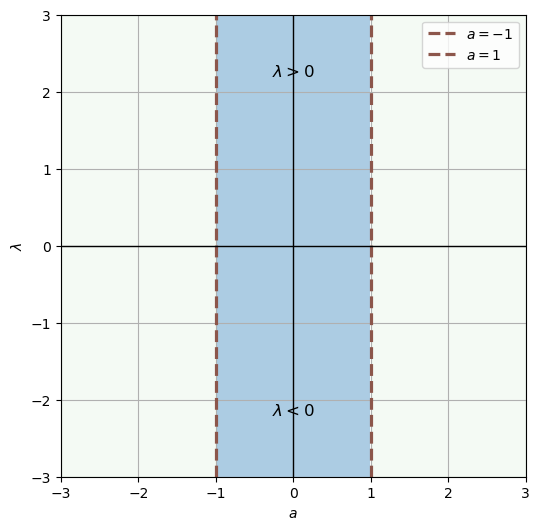

In [4]:
# We are going to make a plot shading these regions
# Import plotting library
import matplotlib.pyplot as plt

# Array for a
a = np.linspace(-3, 3, 400)

plt.figure(figsize=(6,6))

# Vertical boundary lines determined by a
plt.axvline(-1, linestyle='--', color='C5', linewidth = 2.3)
plt.axvline(1, linestyle='--', color='C5', linewidth = 2.3)

# Mark main axis
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Shade regions
plt.fill_between(a, -3, 3, where=(a > -1) & (a < 1), alpha=0.37)
plt.fill_between(a, -3, 3, where=(a <= -1), color='C2', alpha=0.05)
plt.fill_between(a, -3, 3, where=(a >= 1), color='C2', alpha=0.05)

# Labels for lambda regions
plt.text(0, 2.2, r'$\lambda > 0$', color='black', fontsize=12, ha='center')
plt.text(0, -2.2, r'$\lambda < 0$', color='black', fontsize=12, ha='center')

# Axis labels
plt.xlabel(r'$a$')
plt.ylabel(r'$\lambda$')

# Limits
plt.xlim(-3,3)
plt.ylim(-3,3)

plt.legend(['$a=-1$', '$a=1$'])
plt.grid(True)

plt.show()

We have two Hopf bifurcations. The first takes place at $a = -1$ and the second at $a = 1$.

# 3. Calculate the fractal dimension of the following object shown at three successive levels of construction.
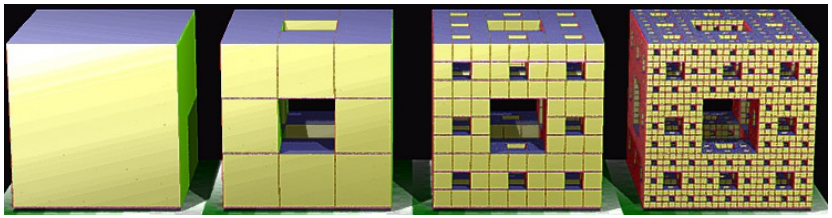

The length of measuring unit is $\epsilon = 3^{-n}$ because each side of a face is divided in 3. Now, to count the boxes we use a Rubik's cube.
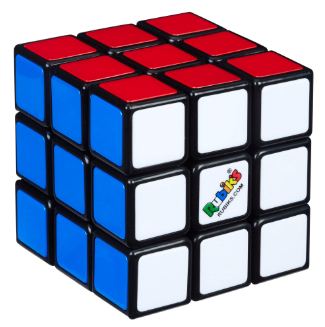

On the first level of construction $N(\epsilon) = 27 - 7 = 20$. The key is that apart from the 6 central boxes removed of each face of the cube, the box  at the center of the cube has also been removed. So, $N(\epsilon) = 20^{n}.$

Finally, the fractal dimension is,
$$
D_f = -\lim_{\epsilon \to 0} \frac{\log N(\epsilon)}{\log(\epsilon)},
$$
In the limit, we have,
$$
D_f = -\frac{\log20^{n}}{\log3^{-n}},
$$
$$
D_f = -\left(\frac{n}{-n}\right)\frac{\log 20}{\log 3}
$$
$$
D_f = \frac{\log20}{\log3} \approx 2.72683.
$$
The fractal dimension is less than 3.

# 4. Consider the map 
$$
x_{n+1} = f(x_n) = \left(2x_n^{2/3}-1\right)^3,
$$
for $x_n \in [-1, 1].$

## a) Show, by iterating two close initial conditions, that this map is chaotic.

In [5]:
# Define the map
def map_4(x0, n):
    '''
    Computes the map given an initial value x0.
    Input: x0 -> (float).
    Output: x -> (list, evolution of the initial condition).
    '''
    # Define the initial value
    x = [x0]

    # Define the map
    for i in range(n + 1):
        new = (2 * x[i]**(2/3) - 1)**3
        # Append results
        x.append(new)
    # Convert to array
    x = np.array(x)

    return x    

In [6]:
# We iterate two very close initial conditions
x01 = 0.999999
x02 = 0.999998

# Define number of iterations
n = 10
# Iterate
x1 = map_4(x01, n)
x2 = map_4(x02, n)

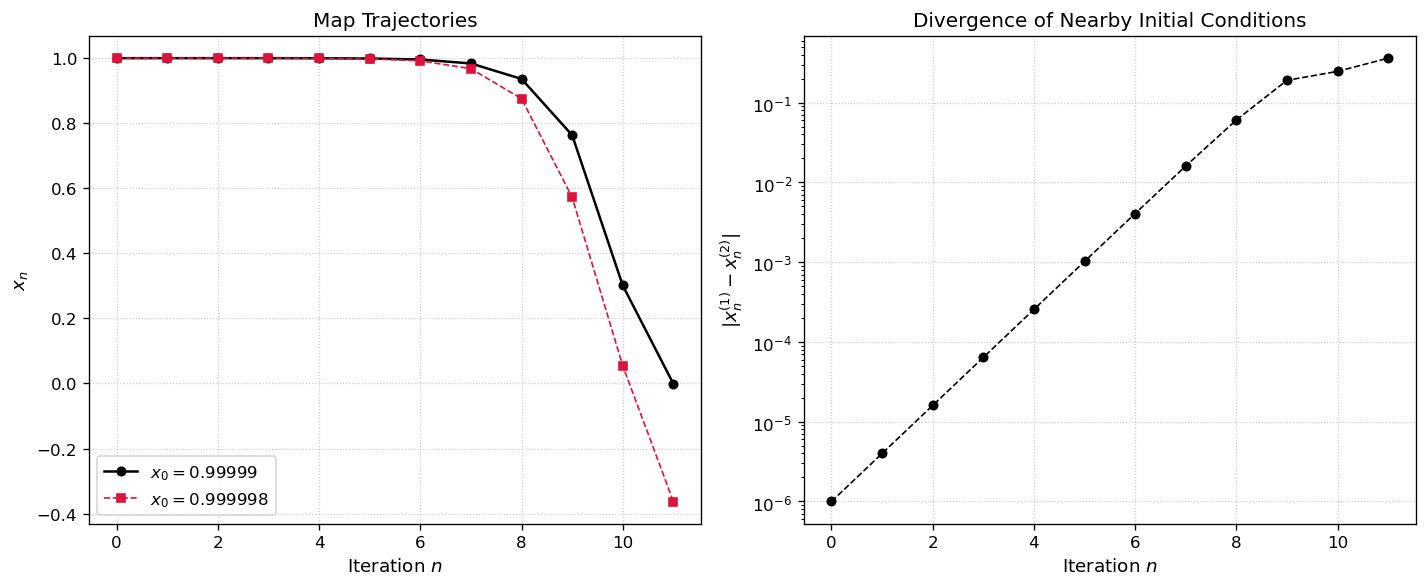

In [7]:
# Plotting
# Iteration axis
iters = np.arange(n+2)

# Difference between trajectories
diff = np.abs(x1 - x2)

# Create the plots
fig, ax = plt.subplots(1, 2, figsize=(12,5), dpi=120)

# ---- Trajectories ----
ax[0].plot(
    iters, x1,
    linestyle='-',
    linewidth=1.5,
    marker='o',
    markersize=5,
    color='black',
    label=r'$x_0 = 0.99999$'
)

ax[0].plot(
    iters, x2,
    linestyle='--',
    linewidth=1,
    marker='s',
    markersize=5,
    color='crimson',
    label=r'$x_0 = 0.999998$'
)

ax[0].set_xlabel('Iteration $n$', fontsize=11)
ax[0].set_ylabel(r'$x_n$', fontsize=11)
ax[0].set_title('Map Trajectories', fontsize=12)

ax[0].legend(frameon=True)
ax[0].grid(True, linestyle=':', linewidth=0.7, alpha=0.7)

# ---- Divergence ----
ax[1].plot(
    iters, diff,
    linestyle='--',
    linewidth=1,
    marker='o',
    markersize=5,
    color='black'
)

ax[1].set_xlabel('Iteration $n$', fontsize=11)
ax[1].set_ylabel(r'$|x_n^{(1)} - x_n^{(2)}|$', fontsize=11)
ax[1].set_title('Divergence of Nearby Initial Conditions', fontsize=12)

ax[1].set_yscale('log')

ax[1].grid(True, linestyle=':', linewidth=0.7, alpha=0.7)

plt.tight_layout()
plt.show()

The sensible dependence on initial conditions is a characteristic of chaotic behavior.

## b) Show that
$$
x_n = \cos^3\!\left(2^n \cos^{-1}(x_0^{1/3})\right)
$$
is a solution $\forall n$.

We'll need to replace this solution on the right hand side of the map. For this, we define an initial angle $\theta_0 = \cos^{-1}(x_0^{1/3})$. Thus, $x_0^{1/3} = \cos \theta_0$. Then, the solution is given by,
$$
x_n = \cos^3\!\left(2^n \cos^{-1}(\cos \theta_0)\right),
$$
$$
x_n = \cos^3\!\left(2^n \theta_0 \right).
$$
We now replace this solution on the map to check if it satisfies the equation.
$$
x_{n+1} = \left(2\cos^2\!\left(2^n \theta_0 \right)-1\right)^3,
$$
$$
x_{n+1} = \cos^3\!\left(2 \cdot 2^n \theta_0 \right),
$$
$$
x_{n+1} = \cos^3\!\left(2^{n+1} \theta_0 \right),
$$
$$
x_{n+1} = \cos^3\!\left(2^{n+1} \cos^{-1}(x_0^{1/3}) \right).
$$
We used the trigonometric identity $ \cos (2x) = 2 \cos²(x) - 1$. Thus, we have recovered the map for the given solution. Therefore,
$$
x_n = \cos^3\!\left(2^n \cos^{-1}(x_0^{1/3})\right)
$$
is a solution $\forall n$. 

# 5. The evolution of a system is described by the following equation
$$
\dddot{x} + a\ddot{x} + \dot{x} - |x| + 1 = 0, 
\qquad a>0.
$$

## a) Is this system dissipative?

We start by reducing the order of the system to 3 differential equations of order 1.
$$
\begin{cases}
\dot{x} = y, \\
\dot{y} = z, \\
\dot{z} = |x| - az - y - 1.
\end{cases}
$$
Now, to compute if the system is dissipative we need to find the divergence of this system of order 1.
$$
\nabla \cdot \mathbf{f} = \frac{d f_1}{dx} + \frac{d f_2}{dy} + \frac{d f_3}{dz},
$$
$$
\nabla \cdot \mathbf{f} = 0 + 0 - a = -a.
$$
Since $a > 0$, we have that $\nabla \cdot \mathbf{f} < 0$ and thus the system is dissipative and it has an attractor in phase space.

## b) Find the fixed points of this system.

The fixed points are given by,
$$
f_1(x^*,y^*) = y^* = 0,
$$
$$
f_2(x^*,y^*) = z^* = 0,
$$
$$
f_3(x^*,y^*) = |x^*| - az^* - y^* - 1= 0.
$$
$$
\Rightarrow |x^*| = 1
$$
So, we have two fixed points,
$$
\begin{gathered}
(x^*_{1}, y^*_{1}, z^*_{1}) = (1, 0, 0); \\
(x^*_{2}, y^*_{2}, z^*_{2}) = (-1, 0, 0).
\end{gathered}
$$

## c) Plot the attractor of this system in its phase space for $a=0.6$. Is it strange?

In [8]:
# Define the parameter
a = 0.60

# Define the dinamical system
def system_5(t, f, a):
    '''
    Defines the dynamical system given the state vector at a time t.
    Inputs:
    t -> (float, time), 
    f -> (array, state vector),
    a -> (float, parameter).
    Output: [dx, dy, dz] -> (list, evolution of the system)
    '''
    # Extract the initial conditions
    x, y, z = f

    # Define the equations
    dx = y
    dy = z
    dz = np.abs(x) - a*z - y - 1

    return [dx, dy, dz]

In [9]:
# We'll now solve the initial value problem
# Import solver
from scipy.integrate import solve_ivp

# Define some initial conditions
f0 = [0.1, -0.4, -0.3]
# Generate a time array
t_span = (0, 1000)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Call the IVP solver
sol = solve_ivp(system_5, t_span, f0, method='DOP853', t_eval=t_eval, args=(a,))

# Extract the solutions
x = sol.y[0]
y = sol.y[1]
z = sol.y[2]

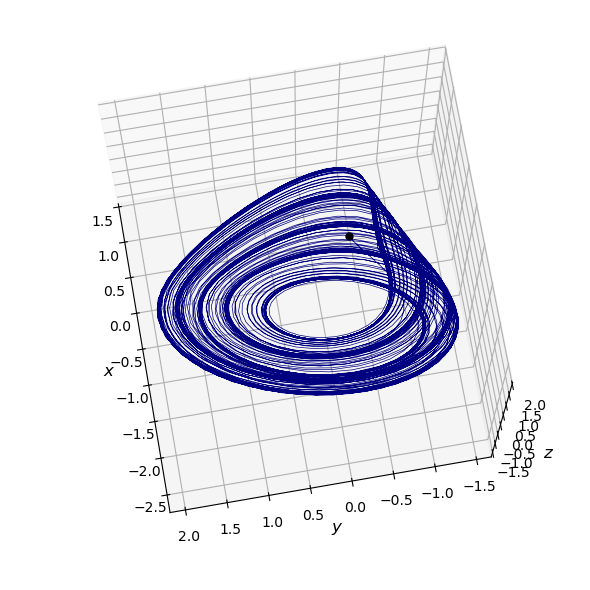

In [10]:
# Plotting
from mpl_toolkits.mplot3d import Axes3D

# Create figure
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectory
ax.plot(x, y, z, color="navy", lw=0.5)

# Mark start point
ax.scatter(x[0], y[0], z[0], color="black", s=25)

# Labels
ax.set_xlabel(r"$x$", fontsize=12)
ax.set_ylabel(r"$y$", fontsize=12)
ax.set_zlabel(r"$z$", fontsize=12)

# Visualization
ax.view_init(elev=75, azim=170, roll=0)

# Light grid
#ax.grid(False, alpha=0.3)

# Improve aspect ratio
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

It looks strange in the sense that the trajectories are stretched and folded repeatedly (fractal nature). Initial conditions in its domain of attraction evolve toward this attractor and exhibit chaotic motion.